# Hidden State Verification & Analysis (Advanced)

This notebook uses the upgraded `Analyser.py` to perform a deep verification of extracted hidden states. It checks file integrity, shape consistency, data quality, and provides rich visualisations.

**What you will learn:**
- Whether your data is probe‑ready.
- Which files are missing or unexpected.
- Whether there are dead neurons, outliers, or other anomalies.
- How the hidden states are distributed across layers.
- Whether the hidden states form meaningful clusters (if labels are available).

All plots are dark‑themed and clearly labelled.

---

In [1]:
import importlib
import Analyser_ as hsv
importlib.reload(hsv)

from IPython.display import HTML, display
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dark theme
display(HTML("""
<style>
body, .jp-Notebook, .jp-OutputArea-output, .jp-RenderedHTMLCommon {
    background-color: #1e1e1e !important;
    color: #d4d4d4 !important;
}
h2, h3, h4 { color: #4fc3f7 !important; }
.highlight {
    background-color: #2d2d2d !important;
    padding: 10px;
    border-left: 4px solid #3498db;
    margin: 4px 0;
    color: #d4d4d4;
}
</style>
"""))

print("Analyser imported. Dark theme applied.")

Analyser imported. Dark theme applied.


## Step 1: Select Model and Dataset

We scan the experiment directory for models that have extraction metadata. Choose a model and dataset by editing the `model_idx` and `dataset_idx` variables, or use interactive widgets.

In [2]:
EXP_ROOT = "/Volumes/Amirali/hidden_states/experiments/baseline_v5_001"
df_all = hsv.analyze_all_models(EXP_ROOT, False, True, True)

display(HTML("<h2>Comprehensive Analysis – All Models & Datasets</h2>"))
display(df_all)

[1/60] Processing EleutherAI/gpt-neo-125m / ISEAR...
  ✓ EleutherAI/gpt-neo-125m/ISEAR -> 1 missing files
[2/60] Processing EleutherAI/gpt-neo-125m / goEmo...
  ✓ EleutherAI/gpt-neo-125m/goEmo -> All checks passed
[3/60] Processing FacebookAI/roberta-base / ISEAR...
  ✓ FacebookAI/roberta-base/ISEAR -> 1 missing files
[4/60] Processing FacebookAI/roberta-base / goEmo...
  ✓ FacebookAI/roberta-base/goEmo -> All checks passed
[5/60] Processing HuggingFaceTB/SmolLM2-1.7B / goEmo...
  ✓ HuggingFaceTB/SmolLM2-1.7B/goEmo -> 6 missing files; linkage issues; 25 layer anomalies; 51200 dead neurons
[6/60] Processing HuggingFaceTB/SmolLM2-135M / ISEAR...
  ✓ HuggingFaceTB/SmolLM2-135M/ISEAR -> 3 missing files; linkage issues; 31 layer anomalies; 17856 dead neurons
[7/60] Processing HuggingFaceTB/SmolLM2-135M / goEmo...
  ✓ HuggingFaceTB/SmolLM2-135M/goEmo -> linkage issues
[8/60] Processing HuggingFaceTB/SmolLM2-360M / ISEAR...
  ✓ HuggingFaceTB/SmolLM2-360M/ISEAR -> 1 missing files; linkage issu

,model,dataset,family,architecture,probe_ready,completion_pct,missing_files,shape_errors,nan_inf,integrity_status,sample_manifest_status,id_linkage_status,layer_anomalies,dead_neurons,outliers,status_message
0,EleutherAI/gpt-neo-125m,ISEAR,GPT-Neo,decoder,False,100.000000,1,0,False,ok,ok,ok,0,0,0,1 missing files
1,EleutherAI/gpt-neo-125m,goEmo,GPT-Neo,decoder,True,100.000000,0,0,False,ok,ok,ok,0,0,0,All checks passed
2,FacebookAI/roberta-base,ISEAR,RoBERTa,encoder,False,100.000000,1,0,False,ok,ok,ok,0,0,0,1 missing files
3,FacebookAI/roberta-base,goEmo,RoBERTa,encoder,True,100.000000,0,0,False,ok,ok,ok,0,0,0,All checks passed
4,HuggingFaceTB/SmolLM2-1.7B,goEmo,SmolLM2,decoder,False,0.000000,6,0,False,not_available,not_available,warning,25,51200,0,6 missing files; linkage issues; 25 layer anom...
5,HuggingFaceTB/SmolLM2-135M,ISEAR,SmolLM2,decoder,False,0.000000,3,0,False,not_available,not_available,error,31,17856,0,3 missing files; linkage issues; 31 layer anom...
6,HuggingFaceTB/SmolLM2-135M,goEmo,SmolLM2,decoder,False,100.000000,0,0,False,ok,ok,error,0,0,0,linkage issues
7,HuggingFaceTB/SmolLM2-360M,ISEAR,SmolLM2,decoder,False,12.940256,1,0,False,ok,ok,error,0,0,0,1 missing files; linkage issues
8,HuggingFaceTB/SmolLM2-360M,goEmo,SmolLM2,decoder,False,100.000000,0,0,False,ok,ok,error,0,0,0,linkage issues
9,Qwen/Qwen2-0.5B,ISEAR,Qwen,decoder,False,0.000000,-1,-1,False,error,error,error,-1,-1,-1,Missing mandatory file: Missing file: /Volumes...


## Step 2: Run Full Analysis

Executes all verification checks, anomaly detection, and generates a multi‑panel figure. The report is printed and returned for further inspection.

In [3]:
# Display table
display(df_all)

,model,dataset,family,architecture,probe_ready,completion_pct,missing_files,shape_errors,nan_inf,integrity_status,sample_manifest_status,id_linkage_status,layer_anomalies,dead_neurons,outliers,status_message
0,EleutherAI/gpt-neo-125m,ISEAR,GPT-Neo,decoder,False,100.000000,1,0,False,ok,ok,ok,0,0,0,1 missing files
1,EleutherAI/gpt-neo-125m,goEmo,GPT-Neo,decoder,True,100.000000,0,0,False,ok,ok,ok,0,0,0,All checks passed
2,FacebookAI/roberta-base,ISEAR,RoBERTa,encoder,False,100.000000,1,0,False,ok,ok,ok,0,0,0,1 missing files
3,FacebookAI/roberta-base,goEmo,RoBERTa,encoder,True,100.000000,0,0,False,ok,ok,ok,0,0,0,All checks passed
4,HuggingFaceTB/SmolLM2-1.7B,goEmo,SmolLM2,decoder,False,0.000000,6,0,False,not_available,not_available,warning,25,51200,0,6 missing files; linkage issues; 25 layer anom...
5,HuggingFaceTB/SmolLM2-135M,ISEAR,SmolLM2,decoder,False,0.000000,3,0,False,not_available,not_available,error,31,17856,0,3 missing files; linkage issues; 31 layer anom...
6,HuggingFaceTB/SmolLM2-135M,goEmo,SmolLM2,decoder,False,100.000000,0,0,False,ok,ok,error,0,0,0,linkage issues
7,HuggingFaceTB/SmolLM2-360M,ISEAR,SmolLM2,decoder,False,12.940256,1,0,False,ok,ok,error,0,0,0,1 missing files; linkage issues
8,HuggingFaceTB/SmolLM2-360M,goEmo,SmolLM2,decoder,False,100.000000,0,0,False,ok,ok,error,0,0,0,linkage issues
9,Qwen/Qwen2-0.5B,ISEAR,Qwen,decoder,False,0.000000,-1,-1,False,error,error,error,-1,-1,-1,Missing mandatory file: Missing file: /Volumes...


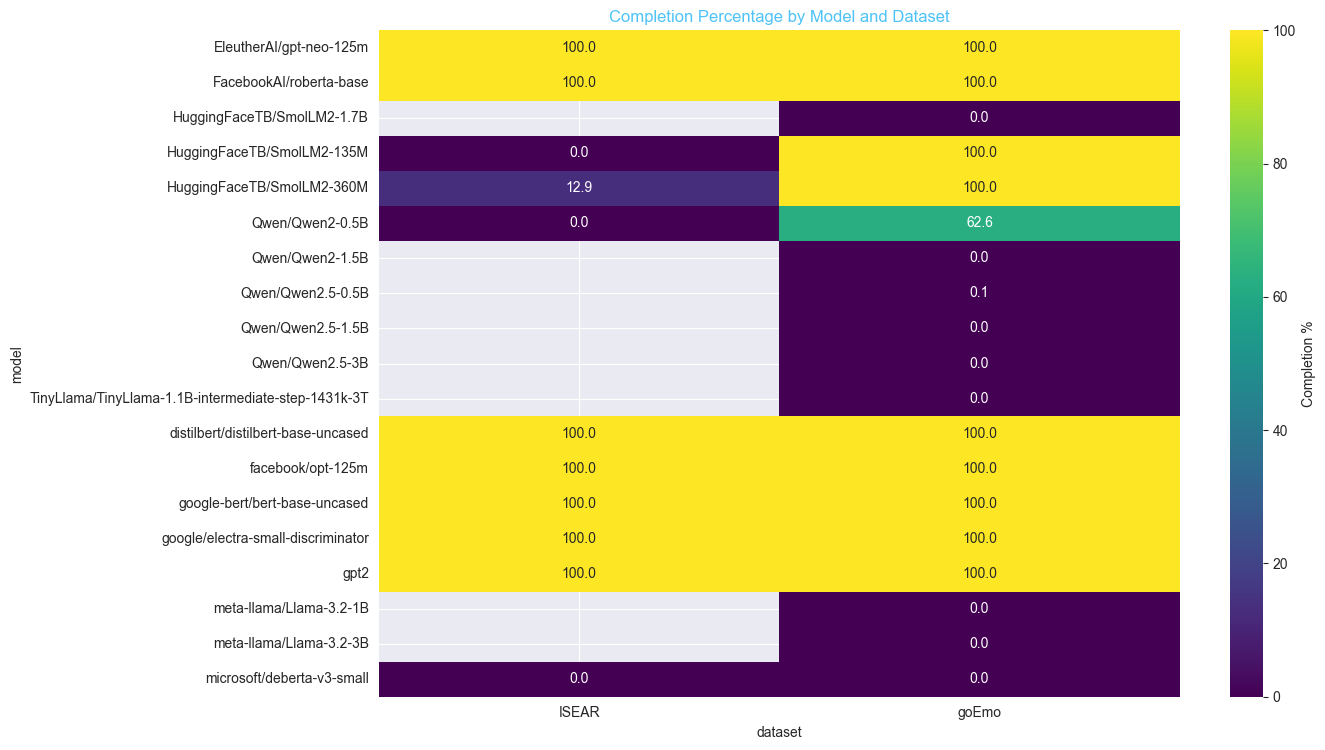

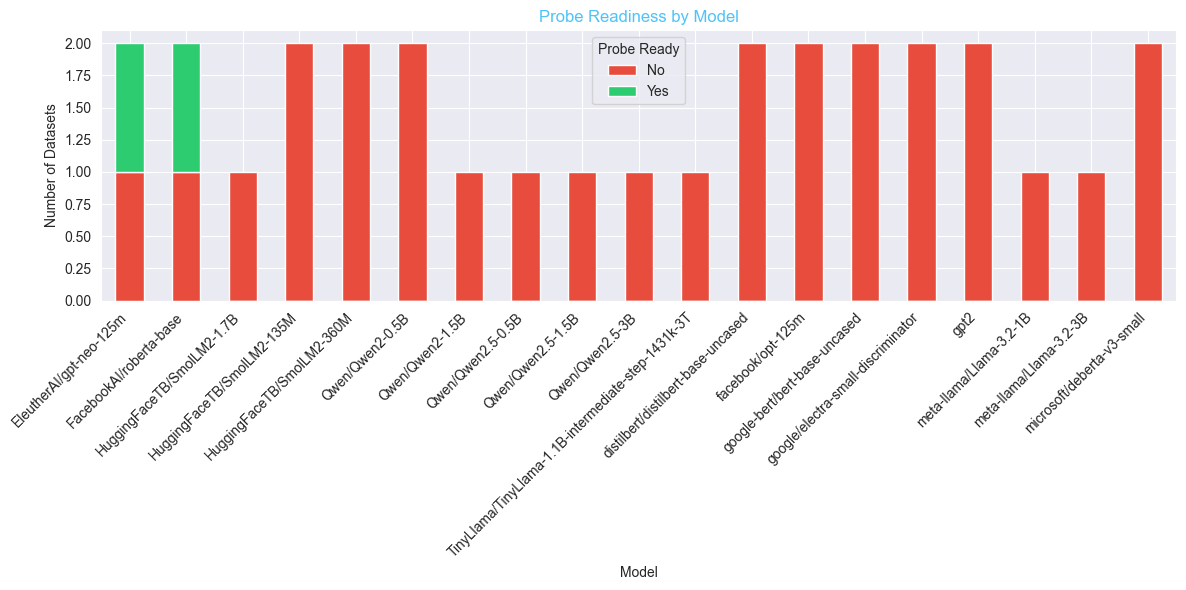

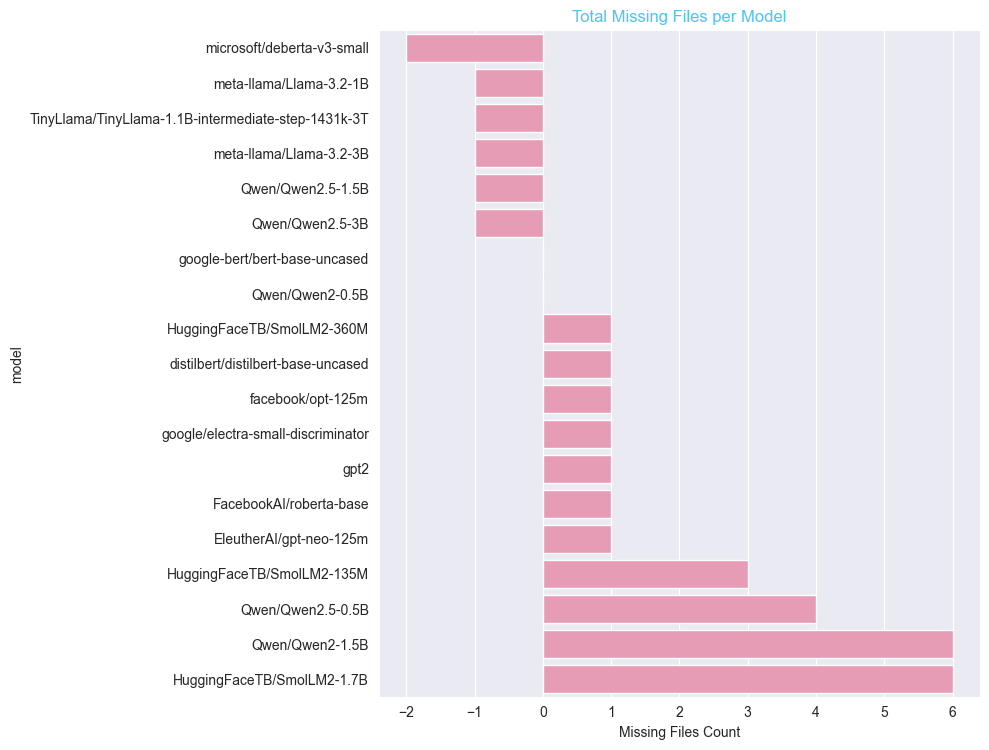

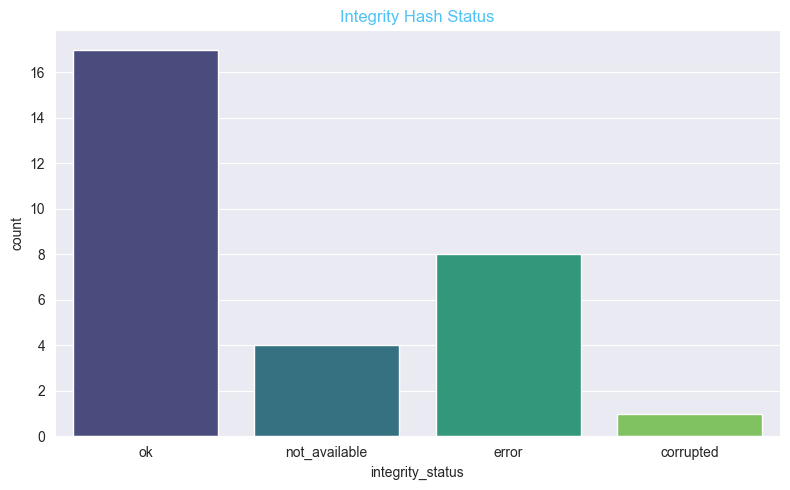

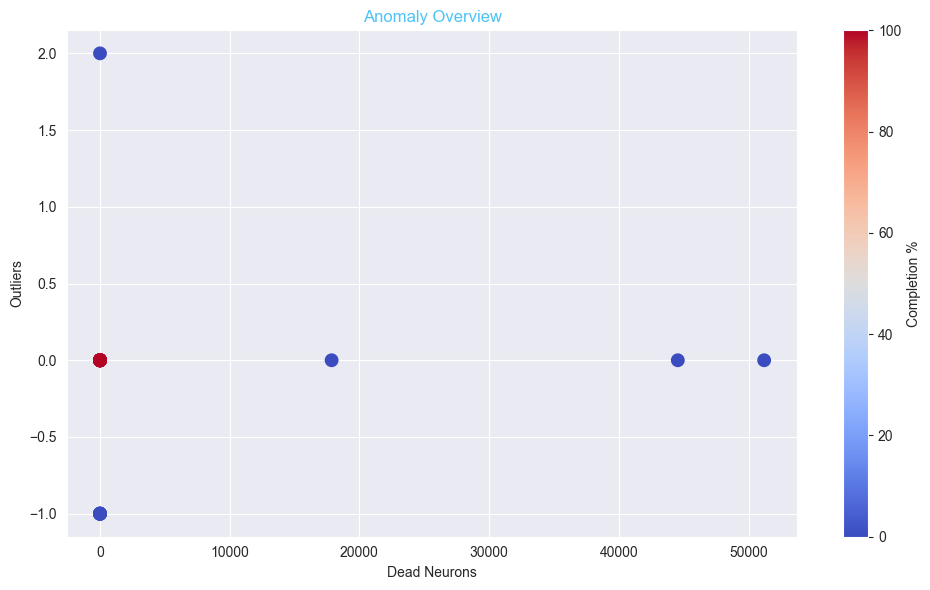

In [4]:
# Generate plots
hsv.plot_summary(df_all)

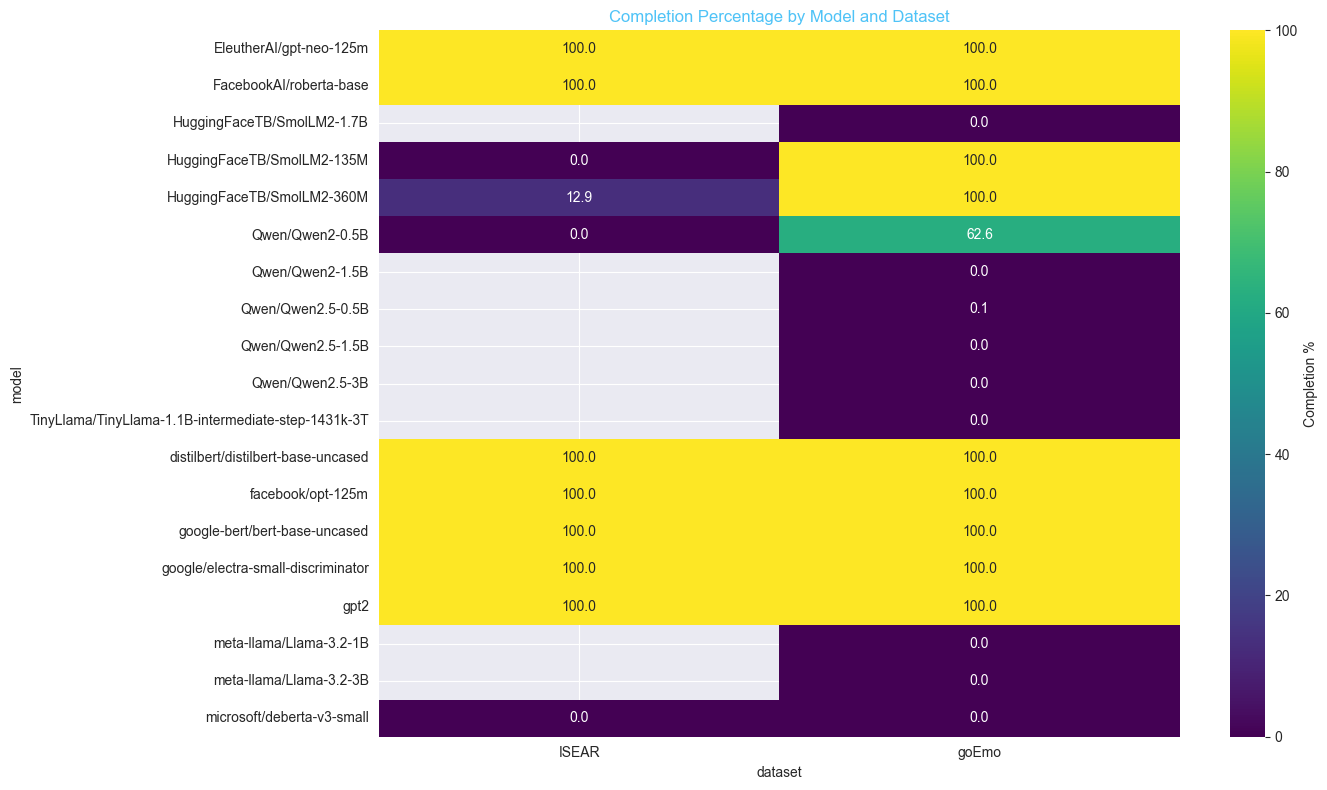

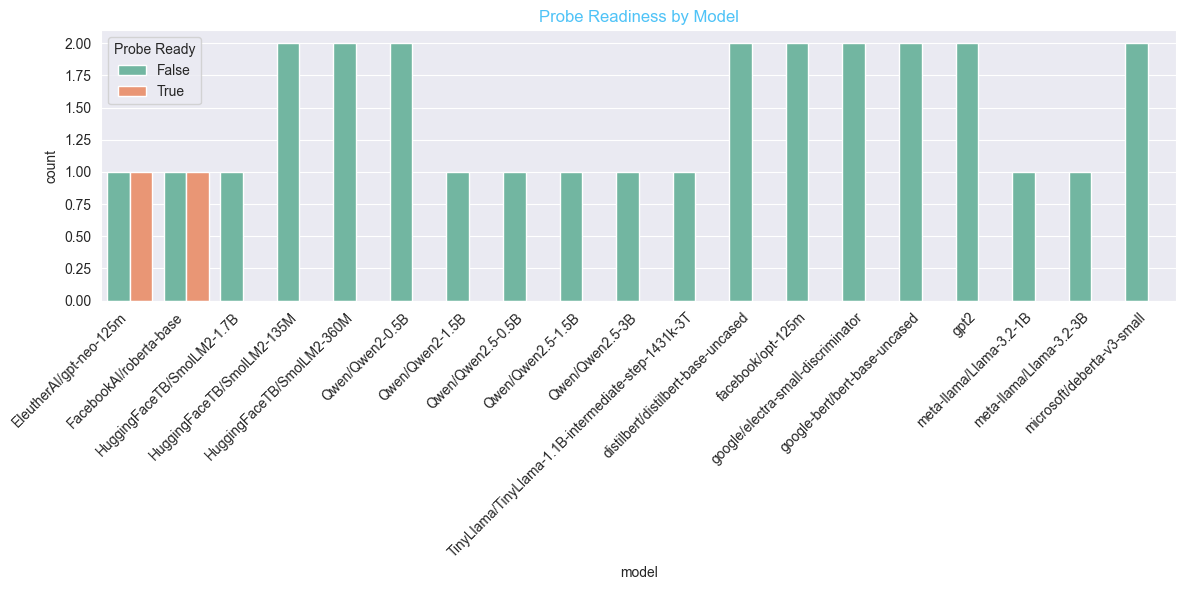

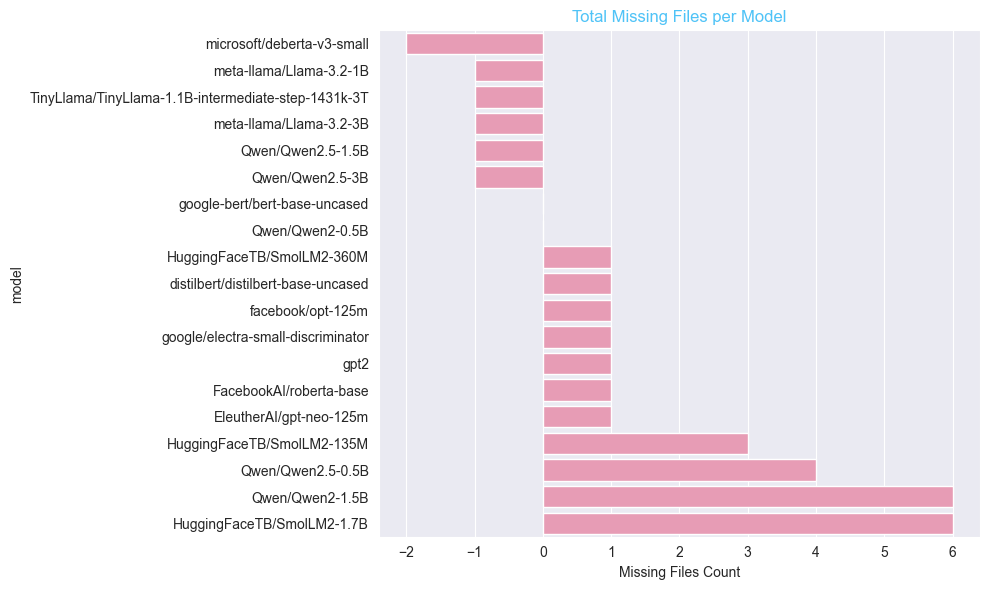

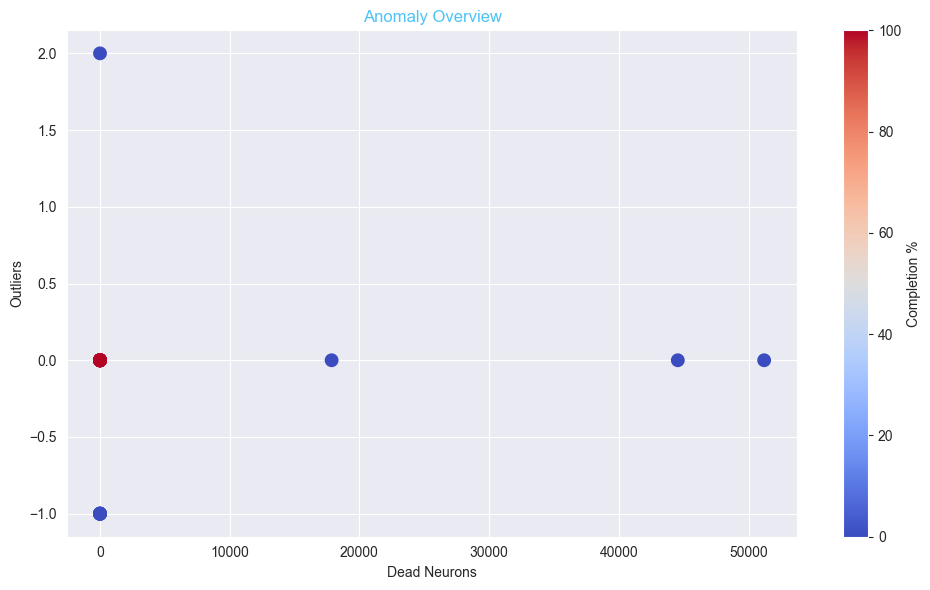

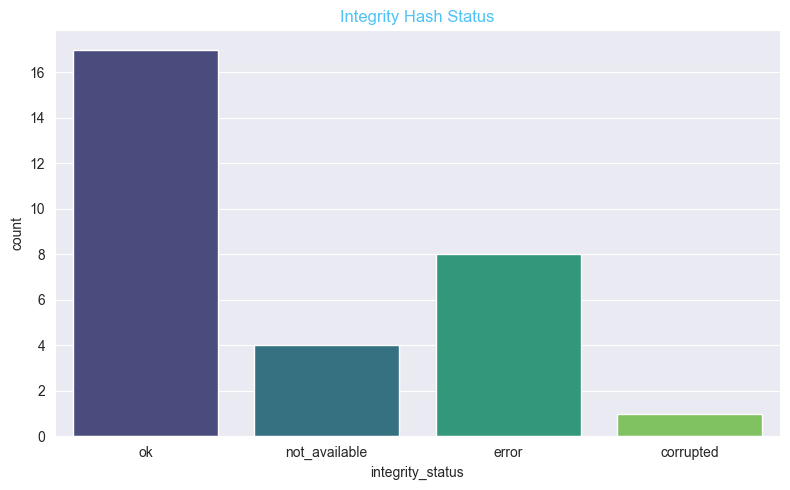

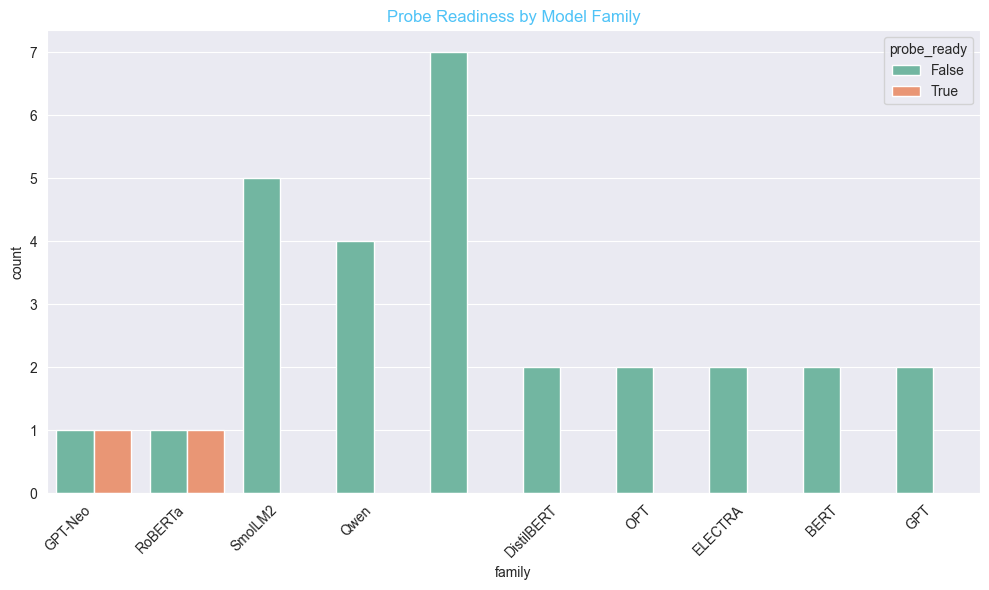

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

if not df_all.empty:
    # 1. Completion percentage heatmap (models vs datasets)
    pivot = df_all.pivot_table(index='model', columns='dataset', values='completion_pct', aggfunc='mean')
    plt.figure(figsize=(14, 8))
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap='viridis', cbar_kws={'label': 'Completion %'})
    plt.title('Completion Percentage by Model and Dataset', color='#4fc3f7')
    plt.tight_layout()
    plt.show()

    # 2. Probe readiness per model (split by dataset)
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df_all, x='model', hue='probe_ready', palette='Set2')
    plt.xticks(rotation=45, ha='right')
    plt.title('Probe Readiness by Model', color='#4fc3f7')
    plt.legend(title='Probe Ready')
    plt.tight_layout()
    plt.show()

    # 3. Missing files per model
    missing = df_all.groupby('model')['missing_files'].sum().sort_values()
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing.values, y=missing.index, color='#f48fb1')
    plt.title('Total Missing Files per Model', color='#4fc3f7')
    plt.xlabel('Missing Files Count')
    plt.tight_layout()
    plt.show()

    # 4. Anomaly scatter (dead neurons vs outliers)
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(df_all['dead_neurons'], df_all['outliers'],
                          c=df_all['completion_pct'], cmap='coolwarm', s=80)
    plt.colorbar(scatter, label='Completion %')
    plt.xlabel('Dead Neurons')
    plt.ylabel('Outliers')
    plt.title('Anomaly Overview', color='#4fc3f7')
    plt.tight_layout()
    plt.show()

    # 5. Integrity status distribution
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_all, x='integrity_status', hue='integrity_status', palette='viridis', legend=False)
    plt.title('Integrity Hash Status', color='#4fc3f7')
    plt.tight_layout()
    plt.show()

    # 6. Family / architecture summary (if available)
    if 'family' in df_all.columns and df_all['family'].notna().any():
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df_all, x='family', hue='probe_ready', palette='Set2')
        plt.xticks(rotation=45, ha='right')
        plt.title('Probe Readiness by Model Family', color='#4fc3f7')
        plt.tight_layout()
        plt.show()
else:
    print("No data found.")